# 0. Import our libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pd.options.display.float_format = '{:,.2f}'.format


# 1. Collecting data
- What subject is your data about? What is the source of your data?  
- Do authors of this data allow you to use like this? You can check the data license  
- How did authors collect data?


## About dataset
### Subject: Commercial flight operations in the United States (2024)

Although air travel is essential for bringing people and economies together, passenger flights are frequently disrupted by delays and cancellations. With over 1 million flights nationwide, this dataset offers a thorough understanding of US airline performance in 2024.

The dataset, which includes comprehensive statistics on departure times, cancellations, flight distances, weather delays, and late aircraft delays, presents a special chance to investigate

It represents the **real-world operation and reliability of the U.S. commercial airline system in 2024**, showing how weather, airline operations, and airport congestion cause **flight delays and cancellations that affect passengers and the national economy**.


### Sources
Kaggle link: [Flight Delay & Cancellation Data (1 Million+ 2024)](https://www.kaggle.com/datasets/nalisha/flight-delay-and-cancellation-data-1-million-2024) \
The On-Time Performance Data (2024) from the US Bureau of Transportation Statistics (BTS) is the source of this dataset. The source offers comprehensive details on airline on-time performance, including departure times, weather-related disruptions, delays, and cancellations.


**Publication date:** 8 Oct 2025

## Data Lisence

**No Copyright** 

The person who associated a work with this deed has dedicated the work to the public domain by waiving all of his or her rights to the work worldwide under copyright law, including all related and neighboring rights, to the extent allowed by law. 

You can copy, modify, distribute and perform the work, even for commercial purposes, all without asking permission. See Other Information via the link below. 

[CC0: Public Domain](https://creativecommons.org/publicdomain/zero/1.0/)



## Collection Methodology

The information was gathered from the 2024 On-Time Performance reports published by the US Bureau of Transportation Statistics (BTS). A single CSV file containing important features, such as delays, cancellations, distances, and weather impacts, was created by merging, cleaning, and curating monthly reports.



* **Target population & sampling:**
  **All scheduled domestic commercial passenger flights in the United States** operated by reporting carriers. This is **near-census data**, not a sample.

* **Time period:**
  **Calendar year 2024** (January–December).

* **Known limitations / biases:**

  * Includes **domestic flights only** (no international legs).
  * Smaller carriers or certain charter flights may be excluded.
  * Delay reasons are **self-reported by airlines**, which may introduce reporting bias.
  * Weather delay attribution can be imperfect or overlapping with other causes.
  * Does not capture passenger-level impacts (missed connections, rebooking experience).


## Why did we choose this dataset?
- What interests your group about this topic?
- What potential questions or insights could this data provide?


**Why we chose this dataset:**

* **Interest:**
  Flight delays and cancellations directly affect millions of passengers and reflect how a large, complex transportation system operates under real-world constraints such as weather, congestion, and limited resources.

* **Potential questions / insights:**

  * What are the main causes of delays and cancellations in U.S. flights?
  * Which airlines, airports, or routes are most reliable?
  * How do weather and late aircraft delays propagate across the network?
  * Can delays or cancellations be predicted in advance using historical patterns?


# 2. Exploring data 
- How many rows and how many columns?  
- What is the meaning of each row?  
- Are there **<span style="color:red">duplicated rows</span>**?  
- What is the meaning of each column?  
- What is the current data type of each column? Are there columns having **<span style="color:red">inappropriate data types</span>**?  
- With each numerical column, how are values distributed?  
  - What is the percentage of **<span style="color:red">missing values</span>**?  
  - Min? max? Are they **<span style="color:red">abnormal</span>**?  
- With each categorical column, how are values distributed?  
  - What is the percentage of **<span style="color:red">missing values</span>**?  
  - How many different values? Show a few  
  - Are they **<span style="color:red">abnormal</span>**?

## Basic Information
- How many rows does your dataset have?
- How many columns does your dataset have?
- What does each row represent? (e.g., one customer, one transaction, one day)
- What is the overall size of the dataset?


#### Get to know our dataframe first!!

In [2]:
df = pd.read_csv("data/flight_data_2024.csv")
df.head(10)

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0
5,2024,1,1,1,1/1/2024,JAX,"Jacksonville, FL",Florida,1403.0,14.0,1417.0,1559.0,4.0,0,102.0,833,0,0
6,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,947.0,26.0,1013.0,1218.0,13.0,0,125.0,833,0,0
7,2024,1,1,1,1/1/2024,CHS,"Charleston, SC",South Carolina,1135.0,8.0,1143.0,1309.0,5.0,0,86.0,641,0,0
8,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,810.0,14.0,824.0,1005.0,8.0,0,101.0,641,0,0
9,2024,1,1,1,1/1/2024,ITH,"Ithaca/Cortland, NY",New York,1248.0,12.0,1300.0,1343.0,12.0,0,43.0,189,0,0


In [3]:
df.tail()

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
1048570,2024,2,29,4,2/29/2024,SJU,"San Juan, PR",Puerto Rico,1447.0,24.0,1511.0,1640.0,7.0,0,149.0,1045,0,0
1048571,2024,2,29,4,2/29/2024,PHX,"Phoenix, AZ",Arizona,59.0,12.0,111.0,647.0,3.0,0,216.0,1972,0,105
1048572,2024,2,29,4,2/29/2024,JAX,"Jacksonville, FL",Florida,2014.0,20.0,2034.0,2128.0,10.0,0,54.0,328,0,0
1048573,2024,2,29,4,2/29/2024,CLT,"Charlotte, NC",North Carolina,1104.0,12.0,1116.0,1210.0,7.0,0,114.0,808,0,70
1048574,2024,2,29,4,2/29/2024,MCI,"Kansas City, MO",Missouri,1307.0,13.0,1320.0,1559.0,22.0,0,99.0,808,0,104


In [4]:
df.shape

(1048575, 18)

- **This dataset** has **1 048 757** rows and **18** columns
* **Each row represents:** a single flight (one origin to one destination) in the time‐span covered by the dataset.

* **Overall size of the dataset:**
  **Over 1 million flight records**, with **dozens of variables** covering timing, delays, cancellations, distance, airline, airport, and delay causes.


## Data Integrity
- Are there any duplicated rows? If yes, how many?
- Should duplicates be kept or removed? (Justify your decision)
- Are all rows complete, or are some entirely empty?

In [5]:
dup_mask = df.duplicated(keep=False) 
dup_count_all = int(dup_mask.sum())
dup_count_excl_first = int(df.duplicated(keep='first').sum())

print(f"Total duplicated rows (including first occurrences marked): {dup_count_all}")
print(f"Duplicated rows excluding the first occurrence (to be removed if needed): {dup_count_excl_first}")

Total duplicated rows (including first occurrences marked): 11664
Duplicated rows excluding the first occurrence (to be removed if needed): 7401


In [6]:
df_no_dups = df.drop_duplicates().copy()
print(f"Rows after drop_duplicates(): {len(df_no_dups)} (was {len(df)})")

Rows after drop_duplicates(): 1041174 (was 1048575)


In [7]:
all_na_rows_mask = df.isna().all(axis=1)
all_na_rows_count = int(all_na_rows_mask.sum())
print(f"Rows that are entirely empty (all NaN value): {all_na_rows_count}")

df_clean = df_no_dups.loc[~all_na_rows_mask].copy()
print(f"Rows after removing entirely empty rows: {len(df_clean)}")

Rows that are entirely empty (all NaN value): 0
Rows after removing entirely empty rows: 1041174
Rows after removing entirely empty rows: 1041174


### Data Integrity — Summary
- Duplicated rows: 11664
- Decision on duplicates: exact duplicates provide no new information and can bias aggregate statistics; we remove them via `df.drop_duplicates()`.
- Entirely empty rows: reported above; if any exist, they are removed.
- Clean working frame for subsequent steps: `df_clean` (duplicates dropped and empty rows removed).

## Column Inventory
- What is the meaning/definition of each column?
- Which columns are relevant to potential analysis?
- Are there any columns that should be dropped? Why?

### 1. The meaning of each column?
| **Column name**         | **Meaning**                                                                                                           |
| ----------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **year**                | The year when the flight occurred (e.g., 2024).                                                                       |
| **month**               | The month number (1 = January, 12 = December).                                                                        |
| **day_of_month**        | The day of the month (1–31).                                                                                          |
| **day_of_week**         | The weekday number (1 = Monday, 7 = Sunday).                                                                          |
| **fl_date**             | The full flight date (month/day/year).                                                                                |
| **origin**              | The **IATA code** of the origin airport (e.g., JFK = John F. Kennedy International Airport).                          |
| **origin_city_name**    | The full city and state of the origin airport (e.g., “New York, NY”).                                                 |
| **origin_state_nm**     | The full name of the U.S. state where the origin airport is located (e.g., “New York”).                               |
| **dep_time**            | The **actual departure time** in local time, usually given in HHMM format (e.g., 1247 → 12:47 PM).                    |
| **taxi_out**            | The number of minutes the aircraft spent **taxiing on the ground before takeoff** (from gate pushback to wheels-off). |
| **wheels_off**          | The actual **time when the aircraft lifted off the runway**, in HHMM local time.                                      |
| **wheels_on**           | The actual **time when the aircraft touched down at the destination**, in HHMM local time.                            |
| **taxi_in**             | The number of minutes spent **taxiing after landing** (from touchdown to gate arrival).                               |
| **cancelled**           | A binary indicator: **0 = not cancelled**, **1 = cancelled**.                                                         |
| **air_time**            | The **total time in the air** (in minutes), equal to `wheels_on - wheels_off` (converted).                            |
| **distance**            | The great-circle **distance between origin and destination** (in miles).                                              |
| **weather_delay**       | Minutes of delay caused by **weather-related issues** (0 if none).                                                    |
| **late_aircraft_delay** | Minutes of delay caused by the **late arrival of the same aircraft** from a previous flight (0 if none).              |


In [8]:
df_clean.head()

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0


### 2. Which columns are relevant to potential analysis?

Most columns are relevant for analyzing **flight performance, delays, and operational efficiency**.

- **Time-based analysis**: `fl_date`, `day_of_week`, `month`
- **Location-based analysis**: `origin`, `origin_city_name`, `origin_state_nm`
- **Operational analysis**: `dep_time`, `taxi_out`, `taxi_in`, `wheels_off`, `wheels_on`, `air_time`
- **Delay and outcome analysis**: `cancelled`, `weather_delay`, `late_aircraft_delay`
- **Control variable**: `distance`

These columns allow the analysis of delay patterns across time, airports, and operational conditions.

### 3. Are there any columns that should be dropped? Why?

Some columns contain **redundant information** and may be removed depending on the analysis goal.

- `year`, `month`, `day_of_month` can be dropped if `fl_date` is used, as they are derived from the same date information.
- `origin_state_nm` may be redundant if `origin_city_name` is sufficient for location-based analysis.
- `wheels_off` and `wheels_on` may be dropped if only `air_time` is required.

However, no columns must be strictly removed, the decision depends on the specific analytical or modeling objectives.


Because everyone knows that the dataset was collected of lights in year 2024, so we can drop `year` column, `wheels_off` and `wheels_on` also can be dropped, because We just want to know how many minutes that customers spend being on air! 

In [9]:
df_clean = df_clean.drop(columns=["year", "wheels_off", "wheels_on"])
df_clean.head()

,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,7.0,0,84.0,509,0,0
1,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,6.0,0,88.0,622,0,0
2,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,8.0,0,61.0,288,0,0
3,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,12.0,0,51.0,288,0,0
4,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,4.0,0,45.0,237,0,0


In [10]:
df.head(100)

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2024,1,1,1,1/1/2024,PVD,"Providence, RI",Rhode Island,1703.0,18.0,1721.0,1846.0,6.0,0,85.0,615,0,0
96,2024,1,1,1,1/1/2024,LEX,"Lexington, KY",Kentucky,602.0,15.0,617.0,711.0,7.0,0,54.0,296,0,0
97,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,821.0,21.0,842.0,1002.0,4.0,0,80.0,431,0,0
98,2024,1,1,1,1/1/2024,RDU,"Raleigh/Durham, NC",North Carolina,1108.0,26.0,1134.0,1235.0,5.0,0,61.0,431,0,0


### Data Types
- What is the current data type of each column?
- Are there columns with inappropriate data types?
- Which columns need type conversion?

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1041174 entries, 0 to 1048574
Data columns (total 15 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   month                1041174 non-null  int64  
 1   day_of_month         1041174 non-null  int64  
 2   day_of_week          1041174 non-null  int64  
 3   fl_date              1041174 non-null  object 
 4   origin               1041174 non-null  object 
 5   origin_city_name     1041174 non-null  object 
 6   origin_state_nm      1041174 non-null  object 
 7   dep_time             1026022 non-null  float64
 8   taxi_out             1025450 non-null  float64
 9   taxi_in              1024898 non-null  float64
 10  cancelled            1041174 non-null  int64  
 11  air_time             1022824 non-null  float64
 12  distance             1041174 non-null  int64  
 13  weather_delay        1041174 non-null  int64  
 14  late_aircraft_delay  1041174 non-null  int64  
dtypes: 

We think that: flight date (fl_date) and actual departure time (dep_time) have inappropriate data type.
- We want to combine it together into **date and time departure of light** which has datetime data type

In [12]:
df_clean["fl_date"] = pd.to_datetime(df_clean["fl_date"], errors='coerce')

df_clean["dep_time_str"] = (
    df_clean["dep_time"]
    .astype("Int64")      # This allows NaNs to stay NaNs
    .astype(str)          # NaNs become the string "<NA>"
    .replace("<NA>", np.nan) # Change them back to real NaNs
    .str.zfill(4)         # Pad the valid numbers
)

In [13]:
df_clean["date_time_dep"] = pd.to_datetime(
    df_clean["fl_date"].dt.strftime("%Y-%m-%d") + " " +
    df_clean["dep_time_str"].str[:2] + ":" +
    df_clean["dep_time_str"].str[2:],
    errors="coerce"
)

In [14]:
df_clean.drop(columns=["dep_time_str", "fl_date", "dep_time"], inplace=True)


In [15]:
df_clean.head()

,month,day_of_month,day_of_week,origin,origin_city_name,origin_state_nm,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,date_time_dep
0,1,1,1,JFK,"New York, NY",New York,31.0,7.0,0,84.0,509,0,0,2024-01-01 12:47:00
1,1,1,1,MSP,"Minneapolis, MN",Minnesota,20.0,6.0,0,88.0,622,0,0,2024-01-01 10:01:00
2,1,1,1,JFK,"New York, NY",New York,21.0,8.0,0,61.0,288,0,0,2024-01-01 14:11:00
3,1,1,1,RIC,"Richmond, VA",Virginia,13.0,12.0,0,51.0,288,0,0,2024-01-01 16:43:00
4,1,1,1,DTW,"Detroit, MI",Michigan,21.0,4.0,0,45.0,237,0,0,2024-01-01 10:10:00


## Numerical Columns Analysis

### Distribution & Central Tendency
- What is the distribution shape? (normal, skewed, bimodal, uniform)
- Create visualizations: histograms, box plots, density plots,…
- Calculate: mean, median, standard deviation

In [16]:

numeric_cols = [
     'taxi_out', 'taxi_in', 'air_time', 'distance','weather_delay', 'late_aircraft_delay'
]

In [17]:
stats = df_clean[numeric_cols].agg(['mean', 'median', 'std', 'skew', 'kurt']).T
print("Basic statistics (mean, median, std, skew, kurt):")
stats


Basic statistics (mean, median, std, skew, kurt):


,mean,median,std,skew,kurt
taxi_out,18.250121,15.0,10.440251,3.516318,22.623252
taxi_in,8.082517,6.0,6.512591,5.666713,95.551071
air_time,116.226956,100.0,70.912036,1.453864,2.928183
distance,835.027019,693.0,592.697875,1.494688,3.116085
weather_delay,1.202810,0.0,20.129097,35.038225,1668.506463
late_aircraft_delay,5.364523,0.0,29.858931,15.747615,452.291327


In [18]:

shape_summary = {}
for c in numeric_cols:
    skew = df[c].skew()
    kurt = df[c].kurt()
    if np.isnan(skew):
        shape = 'insufficient data'
    else:
        if abs(skew) < 0.5:
            shape = 'approximately symmetric'
        elif skew > 0.5:
            shape = 'right-skewed (long right tail)'
        else:
            shape = 'left-skewed (long left tail)'
    peakness = 'heavy tails/high peak' if kurt > 3 else ('light tails/flat' if kurt < 3 else 'mesokurtic')
    shape_summary[c] = {'shape': shape, 'kurtosis_hint': peakness}

print("\nDistribution shape summary (by skew/kurt hints):")
for c, s in shape_summary.items():
    print(f"{c}: \n  | {s['shape']} \n  | {s['kurtosis_hint']} \n -------")



Distribution shape summary (by skew/kurt hints):
taxi_out: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
taxi_in: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
air_time: 
  | right-skewed (long right tail) 
  | light tails/flat 
 -------
distance: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
weather_delay: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
late_aircraft_delay: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------


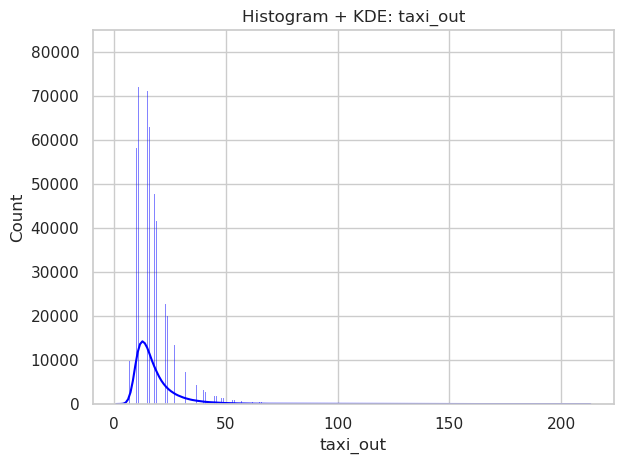

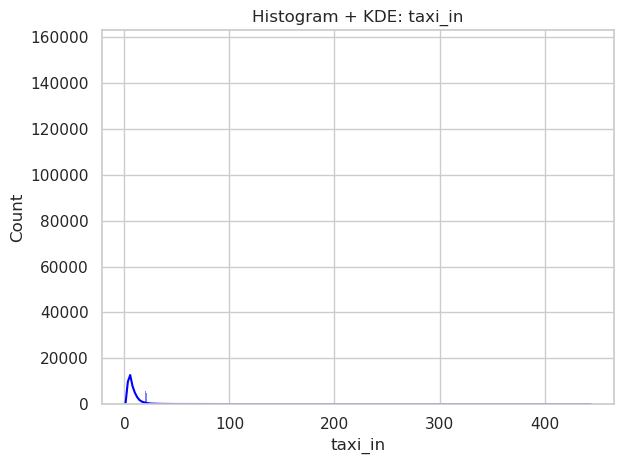

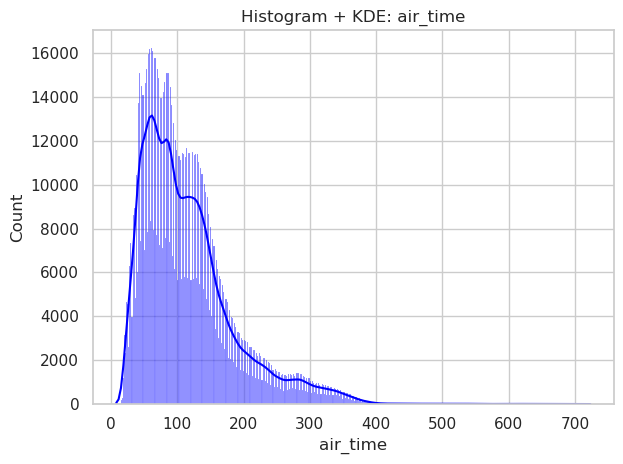

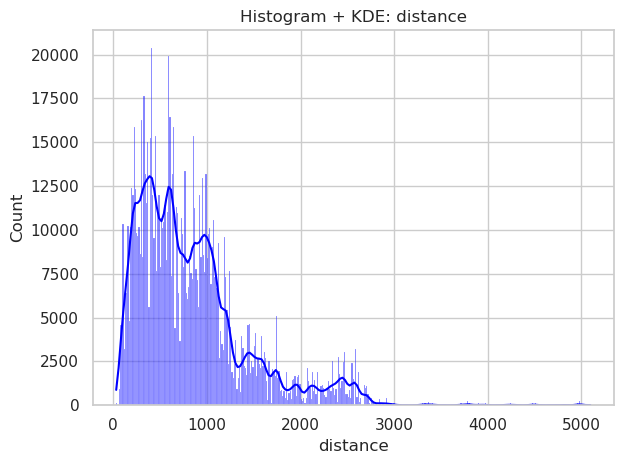

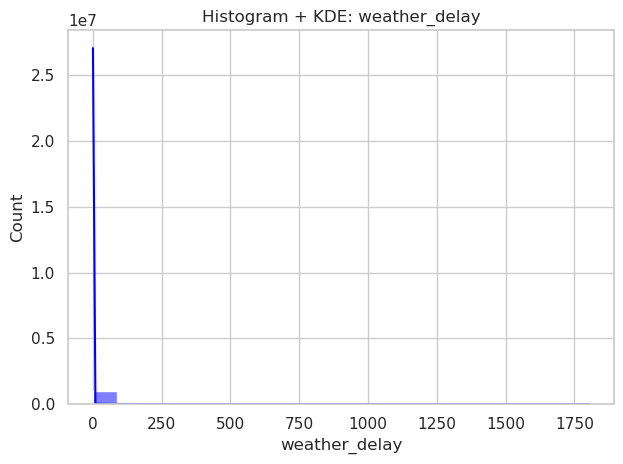

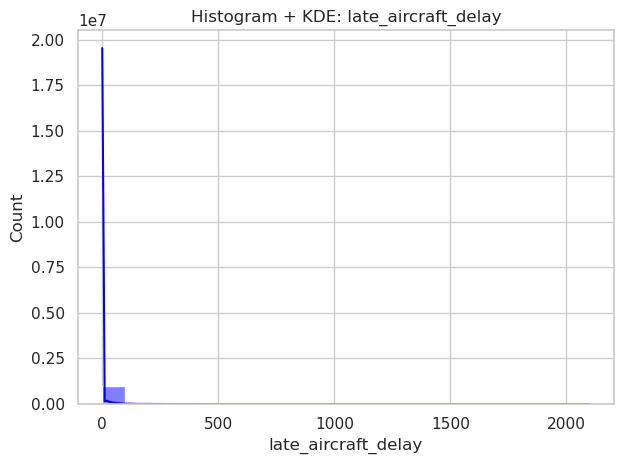

In [19]:
sns.set(style='whitegrid')

plot_df = df[numeric_cols].dropna().copy()

for c in numeric_cols:
    sns.histplot(plot_df[c], kde=True, color='blue')
    plt.title(f"Histogram + KDE: {c}")
    plt.xlabel(c)

    plt.tight_layout()
    plt.show()

### Findings (Distribution & Central Tendency)
- For each numeric column, we computed mean, median, std and examined skewness/kurtosis to infer shape.
- Histograms with KDE are shown for: `air_time`, `distance`, `taxi_out`, `taxi_in`, `weather_delay`, `late_aircraft_delay` (skipping any missing columns).
- Shape interpretation rule of thumb:
  - |skew| < 0.5 ≈ symmetric; skew > 0.5 right-skew; skew < -0.5 left-skew.
  - kurtosis > 3 heavy tails/high peak; kurtosis < 3 light tails/flat; ≈3 mesokurtic.
- You can see printed **“Distribution shape summary”** for a concise per-column shape hint.

### Range & Outliers:
- What are the minimum and maximum values?
- Are min/max values reasonable, or do they indicate errors?
- Identify outliers using box plots, IQR method, or z-scores
- Are outliers genuine extreme values or data entry errors?

In [20]:
#1
min_max = df_clean[numeric_cols].agg(['min','max']).T
print("\nMinimum and maximum values per column:")
min_max


Minimum and maximum values per column:


,min,max
taxi_out,1.0,213.0
taxi_in,1.0,444.0
air_time,8.0,723.0
distance,31.0,5095.0
weather_delay,0.0,1804.0
late_aircraft_delay,0.0,2100.0


#2: **Are min/max values reasonable, or do they indicate errors?**

1. Taxi Times (`taxi_out`, `taxi_in`)

    - Reasonableness: Likely Valid.

    - Analysis: A minimum of 1 minute is very fast but possible at small airports. A maximum taxi_in of 444 minutes (7.4 hours) or taxi_out of 213 minutes (3.5 hours) is extreme. However, these often occur during major ground stops, de-icing queues, or mechanical issues after pushing back. They are likely real events, but they are statistical outliers.
2. Flight Duration (`air_time`, `distance`)

    - Reasonableness: Reasonable.

    - Analysis: 
        - **Distance**: 31 miles is a very short "puddle jumper" or repositioning flight, while 5,095 miles is roughly the distance of a long-haul flight (e.g., New York to Honolulu or London).

        - **Air Time**: 723 minutes (~12 hours) aligns perfectly with the 5,000+ mile distance. 8 minutes of air time is extremely short but can happen in regional ferry flights between very close island or city airports.
3. Delays (`weather_delay`, `late_aircraft_delay`)

    - Reasonableness: Potentially Suspicious / Extreme.

    - Analysis: 
        - A late_aircraft_delay of 2,100 minutes is ~ 35 hours.

        - A weather_delay of 1,804 minutes is ~ 30 hours.

    - Conclusion: While commercial flights are usually canceled rather than delayed for 30+ hours,  aviation datasets sometimes "roll over" delays into the next day if the flight number remains the same, but in this dataset, it's not going to happen.

In [21]:
#Outliers using IQR
q1 = df_clean[numeric_cols].quantile(0.25)
q3 = df_clean[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask_iqr = (df_clean[numeric_cols] < lower) | (df_clean[numeric_cols] > upper)
outlier_counts_iqr = outlier_mask_iqr.sum()
print("\nOutlier counts by IQR rule (1.5*IQR):")
print(outlier_counts_iqr)


Outlier counts by IQR rule (1.5*IQR):
taxi_out               61576
taxi_in                70946
air_time               48052
distance               61001
weather_delay          15895
late_aircraft_delay    99038
dtype: int64


In [22]:
# Outliers using three sigma method
z_scores = (df_clean[numeric_cols] - df_clean[numeric_cols].mean()) / df_clean[numeric_cols].std(ddof=0)
outlier_counts_z3 = (z_scores.abs() > 3).sum()
print("\nOutlier counts by z-score (|z| > 3):")
print(outlier_counts_z3)


Outlier counts by z-score (|z| > 3):
taxi_out               19015
taxi_in                18155
air_time               16333
distance               10218
weather_delay           5140
late_aircraft_delay    15834
dtype: int64


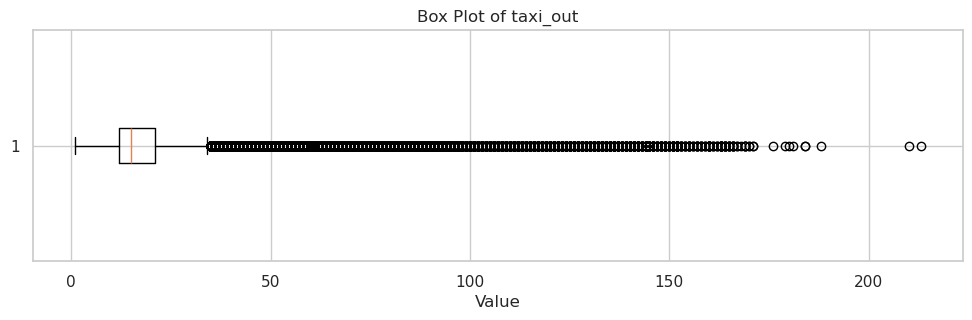

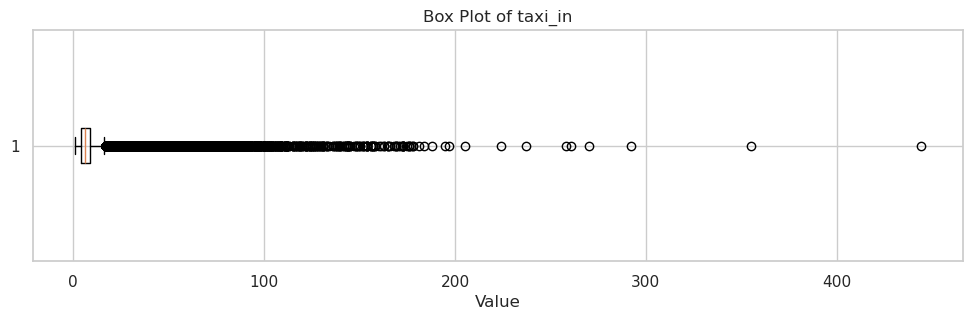

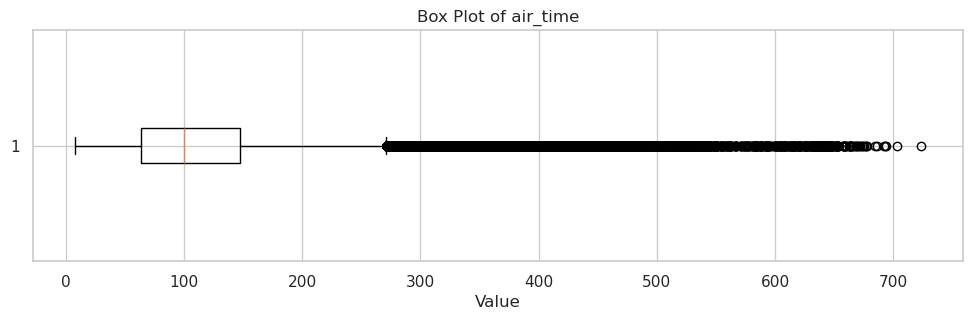

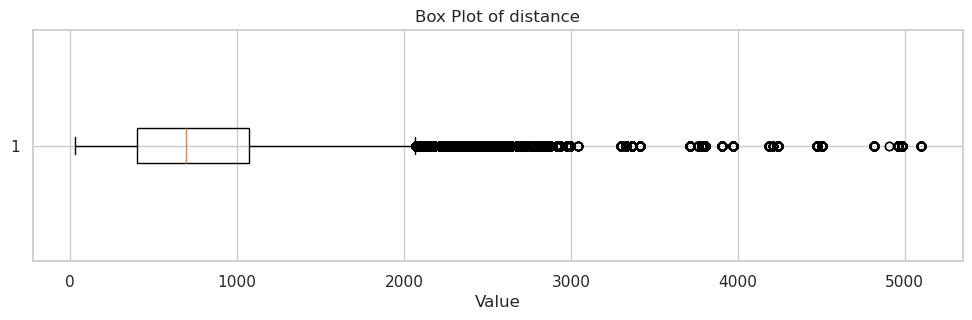

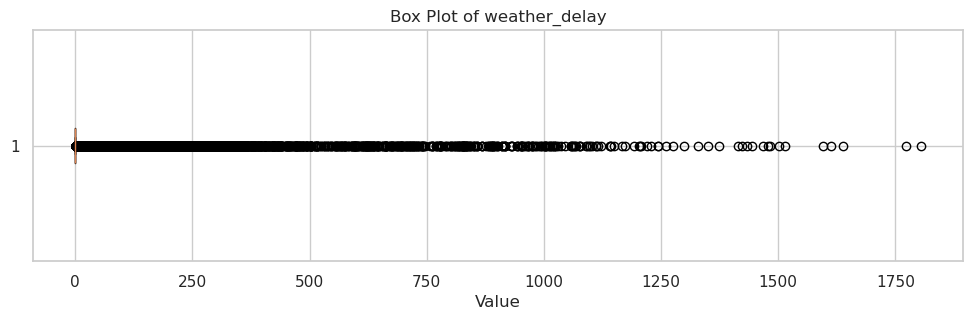

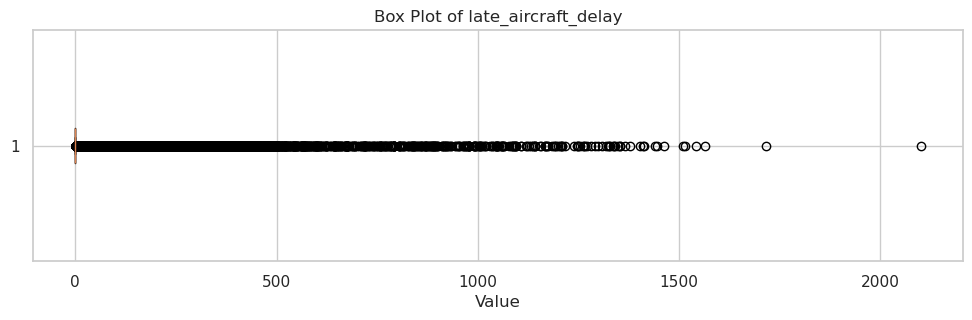

In [23]:
for col in numeric_cols:
    plt.figure(figsize=(12,3))
    plt.boxplot(df_clean[col].dropna(), vert=False) 
    plt.title(f"Box Plot of {col}")
    plt.xlabel("Value") 
    plt.show()

#4 Based on the analysis above, the outliers in your dataset appear to be genuine extreme values rather than data entry errors, though they represent unfortunate events in aviation.

### Data Quality:
- What percentage of values are missing?
- Are there any impossible values? (e.g., negative ages, prices = 0)
- Are there placeholder values? (e.g., 999, -1, 0 used to indicate missing)

In [24]:
# 1) Percentage of missing values per column
missing_pct = df_clean.isna().mean().mul(100).round(4).sort_values(ascending=False)
print("\nMissing value percentage per column (%):")
print(missing_pct)



Missing value percentage per column (%):
air_time               1.7624
taxi_in                1.5632
taxi_out               1.5102
date_time_dep          1.4632
month                  0.0000
day_of_month           0.0000
origin_state_nm        0.0000
origin_city_name       0.0000
origin                 0.0000
day_of_week            0.0000
cancelled              0.0000
distance               0.0000
weather_delay          0.0000
late_aircraft_delay    0.0000
dtype: float64


In [25]:
# 2) Impossible values
# Domain rules: durations and distance should be non-negative
neg_counts = (df_clean[numeric_cols] < 0).sum()
print("\nNegative value counts (should generally be 0):")
print(neg_counts)

# Additional plausibility: distance should not be 0 for a flight; air_time and taxi times rarely 0
extra_checks = {}
if 'distance' in df_clean.columns:
    extra_checks['distance==0'] = int((df_clean['distance'] == 0).sum())
if 'air_time' in df_clean.columns:
    extra_checks['air_time==0'] = int((df_clean['air_time'] == 0).sum())
if 'taxi_out' in df_clean.columns:
    extra_checks['taxi_out==0'] = int((df_clean['taxi_out'] == 0).sum())
if 'taxi_in' in df_clean.columns:
    extra_checks['taxi_in==0'] = int((df_clean['taxi_in'] == 0).sum())
if 'cancelled' in df_clean.columns:
    extra_checks['cancelled_invalid'] = int((~df_clean['cancelled'].isin([0,1])).sum())

print("\nAdditional plausibility checks (counts):")
for k, v in extra_checks.items():
    print(f"- {k}: {v}")



Negative value counts (should generally be 0):
taxi_out               0
taxi_in                0
air_time               0
distance               0
weather_delay          0
late_aircraft_delay    0
dtype: int64

Additional plausibility checks (counts):
- distance==0: 0
- air_time==0: 0
- taxi_out==0: 0
- taxi_in==0: 0
- cancelled_invalid: 0


In [27]:

# 3) Placeholder values: common sentinels like -1, 999, 9999
sentinels = [-1, 999, 9999, 99999]
placeholder_counts = df_clean[numeric_cols].isin(sentinels).sum()
print("\nPlaceholder sentinel counts (-1, 999, 9999, 99999) per numeric column:")
print(placeholder_counts)



Placeholder sentinel counts (-1, 999, 9999, 99999) per numeric column:
taxi_out                 0
taxi_in                  0
air_time                 0
distance               472
weather_delay            0
late_aircraft_delay      1
dtype: int64


We don't make sure it is a true placeholder, because it might be a real distance or a late air craft delay.

## Categorical Columns Analysis

### Value Distribution
- How many unique/distinct values are there?
- What are the top 5-10 most frequent values?
- Create visualizations: bar charts, count plots
- Is the distribution balanced or highly imbalanced?

### Data Quality
- What percentage of values are missing?
- Are there inconsistencies in categories?
    - Example: "Male", "male", "M", "m" all meaning the same thing
    - Example: Typos or variations in spelling
- Are there unexpected or abnormal values?
- Are there categories with very few observations? Should they be grouped?

## Missing Data Analysis
### Overall Assessment:
- Create a missing values summary: column name, count, and percentage missing
- Visualize missing data patterns (heatmap or bar chart)
- Are missing values random, or is there a pattern?
    - Do certain rows or groups have more missing values?

### Per Column Strategy:
- For each column with missing values:
    - Why might values be missing? (random, not applicable, data collection issue)
    - What is your plan to handle them? (remove, impute, keep as separate category)

## Relationships & Correlations
### Preliminary Patterns:
- Calculate correlation matrix for numerical variables
- Create correlation heatmap
- Identify strongly correlated pairs (positive or negative)
- Are there any surprising relationships?

### Cross-tabulations:
- For important categorical × categorical combinations, create frequency tables
- For numerical × categorical combinations, create grouped summary statistics


## Initial Observations & Insights
### Summary:
- What are 3-5 key observations from your exploration?
- What data quality issues did you identify?
- What preprocessing steps will be necessary?
- What interesting patterns emerged that could lead to research questions?

### Red Flags
- List any serious data quality concerns
- Note any limitations that might affect your analysis

# 3. Asking meaningful questions

- Your group needs to give ≥ 2*the-number-of-group-members questions which can be answered with this data.  
- Each question should be meaningful (what are benefits of finding the answer?) and not too easy to answer (e.g., it’s too easy if we just need one line of code to get the answer).  
- Your group should focus more on the quality of questions than the quantity.  
- In notebook file, with each question, your group needs to present:  
  - What is the question?  
  - What are benefits of finding the answer?


Develop meaningful, challenging research questions that will drive your analysis.

### Quantity:

* **$2 \times n$ meaningful questions** that can be answered with your data (e.g., a group of 3 students must formulate 6 questions)
* At least **1 question must require a machine learning model** to answer

### Quality Criteria:

Each question should be:

#### Meaningful:

* Has clear practical or theoretical value
* Provides actionable insights or deeper understanding
* Relates to real-world applications or decision-making

#### Challenging:

* Requires substantial analysis, not just a simple calculation
* Cannot be answered with a single line of code or basic function
* Involves multiple steps: data preparation, analysis, visualization, and interpretation
* Demonstrates analytical depth and critical thinking
Important: Focus on **quality over quantity**. It's better to have fewer well-crafted, insightful questions than many superficial ones. Each question should lead to meaningful discoveries about your data.



### Documentation for Each Question:

In your notebook, present each question with the following structure:

#### 1. The Question

* State your research question **clearly** and **specifically**
* Make it precise enough to be answerable with your data

#### 2. Motivation & Benefits

* Why is this question worth investigating?
* What benefits or insights would be answering this question provide?
* Who would care about the answer? (stakeholders, decision-makers, researchers, etc.)
* What real-world problem or decision does this inform?

# 4. Preprocessing and analyzing data to answer each question

- With each question:  
  - Does it need to have preprocessing step, and if yes, how does your group preprocess?  
    - **Text:** sketch steps [clearly](#) so that readers can understand how your group preprocesses even without reading code  
    - **Code:** implement [sketched](#) steps. Your group should also try to write code clearly (choose good variable names, comment where should be commented, don’t let a line too long)  
  - How does your group analyze data to answer the question?  
    - **Text:** similar to above  
    - **Code:** similar to above


## A. Preprocessing (if needed)

### Written Explanation:

* Describe **preprocessing steps** clearly in markdown
* Sketch the **workflow** so readers understand **without reading code**
* Explain the **logic and reasoning** behind each step
* Use numbered steps or bullet points

---

### Code Implementation:

* Implement each step with **clean, readable code**
* Use **meaningful variable names**
* Add **comments for non-obvious logic** (explain **WHY**, not just WHAT)
* Keep lines **concise (< 100 characters; break long chains across lines)**
* Show intermediate results when helpful

## B. Analysis

### Written Explanation:

* Describe your **analytical approach** in markdown
* Explain what methods you'll use and **why**
* Outline expected outputs (statistics, visualizations, models)
* Write so readers understand methodology **without reading code**

---

### Code Implementation:

* Implement analysis following **code quality standards**:
    * Meaningful variable names
    * Strategic comments
    * Concise, readable lines
    * Proper visualization labels (title, axes, legend)

---

### For ML Questions specifically:

* Explain: **problem setup, data split, models chosen, evaluation metrics**
* Code: **train $\ge 2$ models**, evaluate thoroughly, compare performance, interpret features

---



## C. Results & Interpretation

### Visualizations:

* Create **$2+$ relevant, well-labelled plots** per question
* Proper titles, axis labels, legends, units

### Written Analysis:

* Answer the question **explicitly with evidence**
* Cite specific numbers, patterns from your analysis
* Discuss **practical meaning and implications**
* Note surprises or unexpected findings
* Acknowledge **limitations**

# 5. Project summary
- **Each member:** What difficulties have you encountered?  
- **Each member:** What have you learned?  
- **Your group:** If you had more time, what would you do?


## Keys findings:
- List 3-5 most important insights from your analysis
- Highlight the most interesting or surprising discovery

## Limitations:
- Dataset limitations (sample size, biases, missing data)
- Analysis limitations (methodology constraints, unanswered aspects)
- Scope limitations (what you couldn't address)

## Future Directions (If You Had More Time)

- What additional questions would you explore?
- What deeper analysis would you conduct?
- What alternative methods or approaches would you try?
- What additional data would you seek?
- How could this work be expanded or improved?

## Individual Reflections
Each group member should write a personal reflection covering:
### Challenges & Difficulties Encountered:
- What specific obstacles did you face? (technical, analytical, conceptual)
- How did you overcome them?
- What was most challenging and why?
### Learning & Growth:
- What have you learned? (technical skills, analytical approaches, domain
knowledge)
- What surprised you most?
- How has this project shaped your understanding of data science?


# 6. References
- To finish this project, what materials have you consulted

# 7. Some general points:

- In notebook file, one important thing your group should try to practice is to **[organize sections](#)** and **[write/code clearly](#)**.  
  Your group should use Markdown headings to organize sections, and use Jupyter Notebook/Lab TOC to quickly navigate through headings (it’s similar to bookmark in pdf file).  
  During the process of writing/coding, try to maintain a calm mind, try to **[think for readers](#)**.

- In data science process your group needs to do, I think the most time-consuming part is **[from finding data to giving meaningful questions which can be answered with data](#)**.

